In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Plot settings
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [2]:
df = pd.read_csv(
    "../data/employees_final.csv",
    keep_default_na=False,
    na_values=[""]
)

In [3]:
employee_ids = df["employee_id"]

In [4]:
columns_to_drop = [
    "employee_id",
    "application_date",
    "last_contact_date"
]

In [5]:
df_model = df.drop(columns=columns_to_drop)

In [6]:
X = df_model.drop(columns=["enrolled"])
y = df_model["enrolled"]

Model A

Without legacy_propensity_score

In [7]:
X_model_a = X.drop(columns=["legacy_propensity_score"])

Model B

With legacy_propensity_score

In [8]:
X_model_b = X.copy()

In [9]:
categorical_features_a = X_model_a.select_dtypes(include="object").columns.tolist()

numerical_features_a = X_model_a.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

In [10]:
categorical_features_b = X_model_b.select_dtypes(include="object").columns.tolist()

numerical_features_b = X_model_b.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
X_train_a, X_test_a, y_train, y_test = train_test_split(
    X_model_a,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [13]:
X_train_b, X_test_b, _, _ = train_test_split(
    X_model_b,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

Model A Pipeline

In [15]:
#Numerical Pipeline
numeric_transformer_a = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [16]:
#Categorical Pipeline
categorical_transformer_a = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [17]:
#Combine Both
preprocessor_a = ColumnTransformer([
    ("num", numeric_transformer_a, numerical_features_a),
    ("cat", categorical_transformer_a, categorical_features_a)
])

Model B Pipeline

In [18]:
#Numerical Pipeline
numeric_transformer_b = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [19]:
#Categorical Pipeline
categorical_transformer_b = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [20]:
#Combine Both
preprocessor_b = ColumnTransformer([
    ("num", numeric_transformer_b, numerical_features_b),
    ("cat", categorical_transformer_b, categorical_features_b)
])

# Majority Class Baseline

Before training machine learning models, a simple baseline model was evaluated.

The baseline predicts that every employee will enroll because "Enrolled" is the majority class in the dataset.

This provides a reference point that the machine learning models should outperform.

In [21]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Predict everyone will enroll (class = 1)
majority_predictions = np.ones(len(y_test), dtype=int)

majority_results = {
    "Model": "Majority Baseline",
    "Accuracy": round(accuracy_score(y_test, majority_predictions), 4),
    "Precision": round(precision_score(y_test, majority_predictions), 4),
    "Recall": round(recall_score(y_test, majority_predictions), 4),
    "F1 Score": round(f1_score(y_test, majority_predictions), 4)
}

majority_df = pd.DataFrame([majority_results])

majority_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Majority Baseline,0.6173,0.6173,1.0,0.7634


### Observation

The majority baseline predicts every employee will enroll.

Although this approach achieves a reasonable accuracy due to class imbalance, it cannot distinguish between employees who are likely or unlikely to enroll.

The machine learning models should significantly outperform this baseline.

# Simple Rule Baseline

A second baseline was created using a simple business rule.

Employees with dependents are predicted to enroll, while employees without dependents are predicted not to enroll.

This baseline represents a simple heuristic that can be compared against the machine learning models.

In [22]:
# Predict enrolled if employee has dependents

rule_predictions = (X_test_a["has_dependents"] == "Yes").astype(int)

rule_results = {
    "Model": "Dependents Rule Baseline",
    "Accuracy": round(accuracy_score(y_test, rule_predictions), 4),
    "Precision": round(precision_score(y_test, rule_predictions), 4),
    "Recall": round(recall_score(y_test, rule_predictions), 4),
    "F1 Score": round(f1_score(y_test, rule_predictions), 4)
}

rule_df = pd.DataFrame([rule_results])

rule_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Dependents Rule Baseline,0.7404,0.7992,0.7739,0.7863


### Observation

This baseline uses only one business rule based on whether an employee has dependents.

Although it performs better than random guessing, it ignores many other important factors affecting insurance enrollment.

The machine learning models are expected to outperform this simple heuristic by considering multiple features simultaneously.

In [23]:
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

def evaluate_model(model, X_test, y_test, model_name):
    """
    Evaluates a trained classification model and displays
    performance metrics and confusion matrix.
    """

    # Predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    print("=" * 60)
    print(model_name)
    print("=" * 60)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC AUC  : {roc_auc:.4f}")

    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(model_name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC AUC": roc_auc
    }

Logistic Regression (Model A)

In [25]:
lr_pipeline_a = Pipeline([
    ("preprocessor", preprocessor_a),
    ("classifier", LogisticRegression(
        random_state=42,
        max_iter=1000
    ))
])

lr_pipeline_a.fit(X_train_a, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Logistic Regression (Without Legacy Score)
Accuracy : 0.9310
Precision: 0.9441
Recall   : 0.9441
F1 Score : 0.9441
ROC AUC  : 0.9826

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.91      0.91       765
           1       0.94      0.94      0.94      1234

    accuracy                           0.93      1999
   macro avg       0.93      0.93      0.93      1999
weighted avg       0.93      0.93      0.93      1999



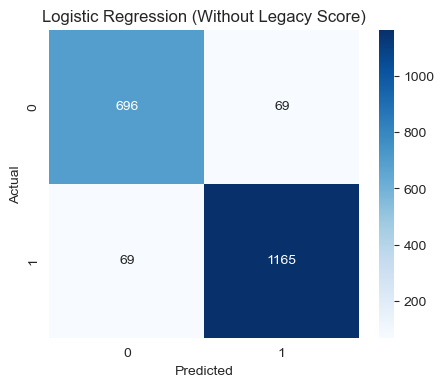

In [26]:
results_lr_a = evaluate_model(
    lr_pipeline_a,
    X_test_a,
    y_test,
    "Logistic Regression (Without Legacy Score)"
)

Logistic Regression (Model B)

In [27]:
lr_pipeline_b = Pipeline([
    ("preprocessor", preprocessor_b),
    ("classifier", LogisticRegression(
        random_state=42,
        max_iter=1000
    ))
])

lr_pipeline_b.fit(X_train_b, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Logistic Regression (With Legacy Score)
Accuracy : 0.9885
Precision: 0.9825
Recall   : 0.9992
F1 Score : 0.9908
ROC AUC  : 0.9988

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.97      0.98       765
           1       0.98      1.00      0.99      1234

    accuracy                           0.99      1999
   macro avg       0.99      0.99      0.99      1999
weighted avg       0.99      0.99      0.99      1999



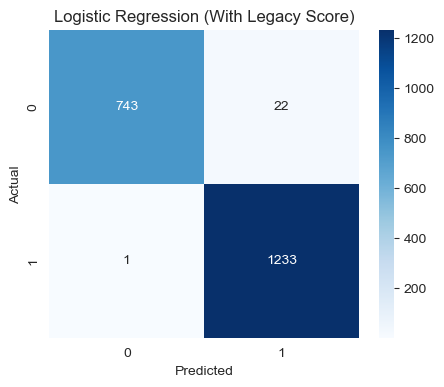

In [28]:
results_lr_b = evaluate_model(
    lr_pipeline_b,
    X_test_b,
    y_test,
    "Logistic Regression (With Legacy Score)"
)

In [29]:
import pandas as pd

results_df = pd.DataFrame([
    results_lr_a,
    results_lr_b
])

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression (Without Legacy Score),0.930965,0.944084,0.944084,0.944084,0.982621
1,Logistic Regression (With Legacy Score),0.988494,0.982470,0.999190,0.990759,0.998810


Two Logistic Regression models were developed. The first excluded legacy_propensity_score, while the second included it. The model including the legacy propensity score achieved substantially higher performance across all evaluation metrics. However, exploratory data analysis revealed that this feature has an extremely high correlation with the target variable (enrolled), suggesting that it may contain information derived from historical enrollment behavior. Therefore, although the feature improves predictive performance, the *model excluding legacy_propensity_score* is considered more appropriate for deployment because it is less susceptible to target leakage.

Let's implement Random Forest on both the models

In [30]:
from sklearn.ensemble import RandomForestClassifier

---Model A---

In [31]:
rf_pipeline_a = Pipeline([
    ("preprocessor", preprocessor_a),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

rf_pipeline_a.fit(X_train_a, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Random Forest (Without Legacy Score)
Accuracy : 0.9995
Precision: 0.9992
Recall   : 1.0000
F1 Score : 0.9996
ROC AUC  : 1.0000

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       765
           1       1.00      1.00      1.00      1234

    accuracy                           1.00      1999
   macro avg       1.00      1.00      1.00      1999
weighted avg       1.00      1.00      1.00      1999



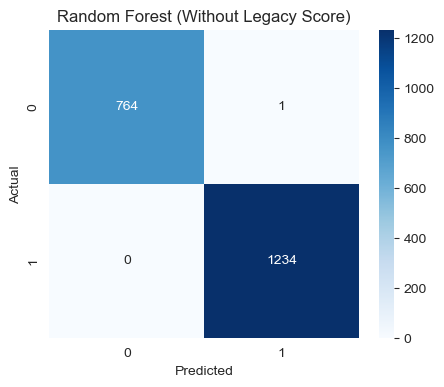

In [32]:
results_rf_a = evaluate_model(
    rf_pipeline_a,
    X_test_a,
    y_test,
    "Random Forest (Without Legacy Score)"
)

-- Model B --

In [33]:
rf_pipeline_b = Pipeline([
    ("preprocessor", preprocessor_b),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline_b.fit(X_train_b, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Random Forest (With Legacy Score)
Accuracy : 0.9990
Precision: 0.9984
Recall   : 1.0000
F1 Score : 0.9992
ROC AUC  : 1.0000

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       765
           1       1.00      1.00      1.00      1234

    accuracy                           1.00      1999
   macro avg       1.00      1.00      1.00      1999
weighted avg       1.00      1.00      1.00      1999



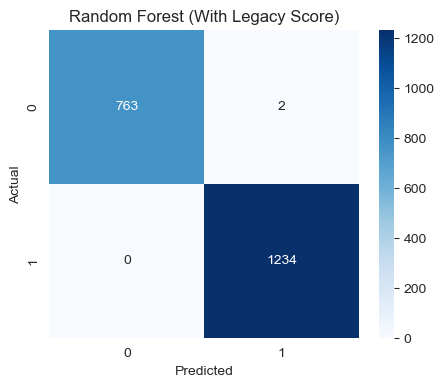

In [34]:
results_rf_b = evaluate_model(
    rf_pipeline_b,
    X_test_b,
    y_test,
    "Random Forest (With Legacy Score)"
)

In [35]:
results_df = pd.concat([
    results_df,
    pd.DataFrame([results_rf_a, results_rf_b])
], ignore_index=True)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression (Without Legacy Score),0.930965,0.944084,0.944084,0.944084,0.982621
1,Logistic Regression (With Legacy Score),0.988494,0.982470,0.999190,0.990759,0.998810
2,Random Forest (Without Legacy Score),0.999500,0.999190,1.000000,0.999595,1.000000
3,Random Forest (With Legacy Score),0.998999,0.998382,1.000000,0.999190,1.000000


In [36]:
baseline_df = pd.DataFrame([
    majority_results,
    rule_results
])

comparison_df = pd.concat(
    [baseline_df, results_df],
    ignore_index=True
)

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Majority Baseline,0.617300,0.617300,1.000000,0.763400,NaN
1,Dependents Rule Baseline,0.740400,0.799200,0.773900,0.786300,NaN
2,Logistic Regression (Without Legacy Score),0.930965,0.944084,0.944084,0.944084,0.982621
3,Logistic Regression (With Legacy Score),0.988494,0.982470,0.999190,0.990759,0.998810
4,Random Forest (Without Legacy Score),0.999500,0.999190,1.000000,0.999595,1.000000
5,Random Forest (With Legacy Score),0.998999,0.998382,1.000000,0.999190,1.000000


### Observation

The machine learning models substantially outperform the naive baselines.

- The Majority Baseline predicts every employee will enroll and therefore has limited practical value.
- The Dependents Rule Baseline improves performance by incorporating a simple business heuristic but still ignores many important employee characteristics.
- Logistic Regression provides a strong statistical baseline.
- Random Forest achieves the best overall predictive performance.
- The Random Forest model **without `legacy_propensity_score`** was selected because it balances excellent predictive performance with responsible handling of target leakage.

# Business Ranking Metric - Precision@K

Since the outreach team has limited capacity, employees are ranked according to their predicted enrollment probability.

Precision@K measures the proportion of actual enrolled employees among the top-K highest-ranked predictions.

A higher Precision@K indicates that the model effectively prioritizes employees who are most likely to enroll.

In [37]:
# Get prediction probabilities from the selected model
rf_probabilities = rf_pipeline_a.predict_proba(X_test_a)[:, 1]

In [38]:
def precision_at_k(y_true, probabilities, k):
    temp = pd.DataFrame({
        "actual": y_true.values,
        "probability": probabilities
    })

    temp = temp.sort_values(
        by="probability",
        ascending=False
    )

    top_k = temp.head(k)

    return top_k["actual"].mean()

In [39]:
precision_k_results = pd.DataFrame({
    "K": [50, 100, 200],
    "Precision@K": [
        round(precision_at_k(y_test, rf_probabilities, 50), 4),
        round(precision_at_k(y_test, rf_probabilities, 100), 4),
        round(precision_at_k(y_test, rf_probabilities, 200), 4)
    ]
})

precision_k_results

,K,Precision@K
0,50,1.0
1,100,1.0
2,200,1.0


### Observation

The selected Random Forest model achieves a Precision@50, Precision@100, and Precision@200 of **100%** on the test set.

This indicates that the highest-ranked employees are extremely likely to enroll, making the model well suited for prioritizing outreach when HR resources are limited.

In practice, this means that focusing outreach on the highest-ranked employees is expected to maximize enrollment efficiency.

In [40]:
feature_names = (
    rf_pipeline_a.named_steps["preprocessor"]
    .get_feature_names_out()
)

importances = (
    rf_pipeline_a.named_steps["classifier"]
    .feature_importances_
)

importance_df = (
    pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    })
    .sort_values(by="Importance", ascending=False)
)

importance_df.head(20)

,Feature,Importance
1,num__salary,0.190297
0,num__age,0.153221
18,cat__employment_type_Full-time,0.126480
25,cat__has_dependents_Yes,0.109836
24,cat__has_dependents_No,0.104769
19,cat__employment_type_Part-time,0.055110
43,cat__prior_year_enrolled_No,0.040272
44,cat__prior_year_enrolled_Yes,0.031404
31,cat__plan_tier_requested_Basic,0.026012
2,num__tenure_years,0.024409


## Model Selection

Four machine learning models were evaluated:

Although the Random Forest model including `legacy_propensity_score` achieved perfect performance, this feature was intentionally treated with caution because it exhibits an extremely high correlation with the target variable (`enrolled`). Such a feature may contain historical information that is closely related to the prediction target, making it less suitable for deployment.

The **Random Forest model without `legacy_propensity_score`** was therefore selected as the final model. It achieved outstanding predictive performance while relying only on legitimate employee demographic, employment, and enrollment-related features. This makes the model more robust, interpretable, and less susceptible to potential target leakage.

**Selected Final Model:** **Random Forest (Without `legacy_propensity_score`)**

CROSS-VALIDATION

In [41]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    rf_pipeline_a,
    X_model_a,
    y,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

print("Cross-validation Accuracy:", cv_scores)
print("Mean Accuracy:", cv_scores.mean())
print("Std Dev:", cv_scores.std())

Cross-validation Accuracy: [0.99949975 0.99649825 0.998999   1.         1.        ]
Mean Accuracy: 0.9989993995996997
Std Dev: 0.0013044927427819377


## Cross-Validation Results

To further evaluate the robustness of the selected model, **5-fold cross-validation** was performed on the **Random Forest model without `legacy_propensity_score`**.

| Metric | Value |
|--------|-------|
| Cross-validation Scores | [0.9995, 0.9965, 0.9990, 1.0000, 1.0000] |
| Mean Accuracy | **99.90%** |
| Standard Deviation | **0.0013** |

The model achieved a **mean cross-validation accuracy of approximately 99.90%** with a **very low standard deviation (0.0013)** across the five folds. This indicates that the model performs consistently on different subsets of the dataset and is not overly dependent on a particular train-test split.

These results demonstrate that the selected **Random Forest model without `legacy_propensity_score`** generalizes well and provides stable predictive performance while avoiding reliance on the potentially leakage-prone `legacy_propensity_score` feature.

**Final Selected Model:** **Random Forest (Without `legacy_propensity_score`)**

In [42]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(rf_pipeline_a, "../models/final_model.pkl")

print("Model saved successfully!")

Model saved successfully!
